<a href="https://colab.research.google.com/github/Shivani-Yadav-CSE/Computer_vision_lab_files/blob/main/labsheet_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Lab Sheet 5: SIFT and HOG Feature Descriptor


!pip install -q opencv-contrib-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

print("Name: Shivani Yadav")
print("CUID: CU24250189")
print("OpenCV Version:", cv2.__version__)

Name: Shivani Yadav
CUID: CU24250189
OpenCV Version: 5.0.0


Name: Shivani Yadav
CUID: CU24250189


Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check.jpg
Name: Shivani Yadav
CUID: CU24250189
Number of Keypoints Detected: 888


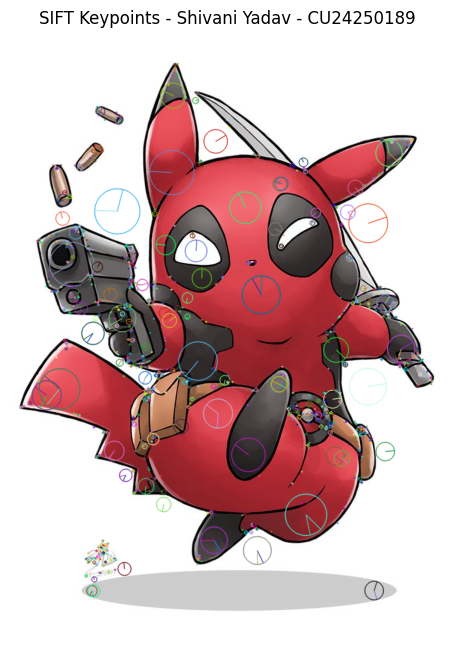


First 10 Keypoints:
Keypoint 1: X=18.46, Y=623.02, Size/Scale=4.23, Angle=187.00°
Keypoint 2: X=22.65, Y=621.38, Size/Scale=2.99, Angle=356.55°
Keypoint 3: X=32.97, Y=616.08, Size/Scale=5.03, Angle=192.88°
Keypoint 4: X=46.03, Y=347.76, Size/Scale=3.15, Angle=177.93°
Keypoint 5: X=48.01, Y=580.93, Size/Scale=4.39, Angle=215.19°
Keypoint 6: X=49.03, Y=348.66, Size/Scale=2.15, Angle=46.11°
Keypoint 7: X=49.03, Y=348.66, Size/Scale=2.15, Angle=358.91°
Keypoint 8: X=49.67, Y=344.16, Size/Scale=2.84, Angle=229.80°
Keypoint 9: X=49.87, Y=349.11, Size/Scale=3.14, Angle=3.47°
Keypoint 10: X=49.87, Y=349.11, Size/Scale=3.14, Angle=45.89°


In [ ]:
 # Experiment 1: SIFT Keypoint Detector and Visualizer

import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
image = cv2.imread(filename)

if image is None:
    raise ValueError("Image could not be loaded.")

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints and descriptors
keypoints, descriptors = sift.detectAndCompute(gray, None)

print("Name: Shivani Yadav")
print("CUID: CU24250189")
print("Number of Keypoints Detected:", len(keypoints))

# Draw keypoints with scale and orientation
output = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display
plt.figure(figsize=(12, 8))
plt.imshow(output)
plt.title("SIFT Keypoints - Shivani Yadav - CU24250189")
plt.axis("off")
plt.show()

# Display some keypoint information
print("\nFirst 10 Keypoints:")
for i, kp in enumerate(keypoints[:10]):
    print(
        f"Keypoint {i+1}: "
        f"X={kp.pt[0]:.2f}, "
        f"Y={kp.pt[1]:.2f}, "
        f"Size/Scale={kp.size:.2f}, "
        f"Angle={kp.angle:.2f}°"
    )

Name: Shivani Yadav
CUID: CU24250189

Please select TWO images.
Image 1 = First image
Image 2 = Second image
The two images should contain the same object or scene.



Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (2).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (2).jpg

Image 1: doreamon and her sister 🎀 (2).jpg
Image 2: 30 Best Pikachu Illustration Ideas You Should Check (2).jpg

Number of keypoints in Image 1: 644
Number of keypoints in Image 2: 888
Total matches: 644
Good matches: 26


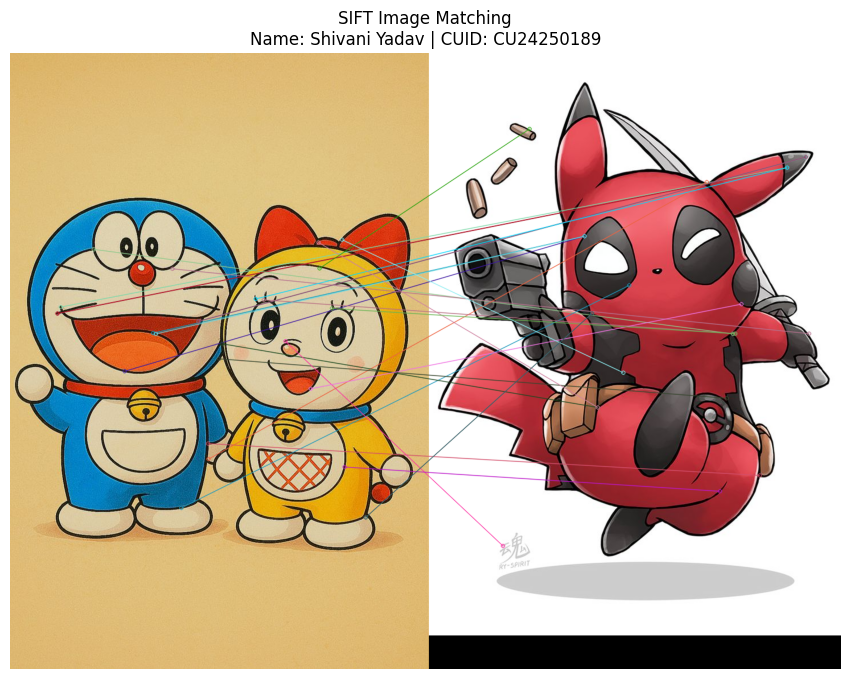


SIFT image matching completed successfully.


In [ ]:

# ============================================================
# Experiment 2: SIFT Image Matching
# Name: Shivani Yadav
# CUID: CU24250189
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# STEP 1: Upload TWO images
# ------------------------------------------------------------
print("\nPlease select TWO images.")
print("Image 1 = First image")
print("Image 2 = Second image")
print("The two images should contain the same object or scene.\n")

uploaded = files.upload()

filenames = list(uploaded.keys())

# Check number of uploaded images
if len(filenames) != 2:
    print("\nERROR: You uploaded", len(filenames), "image(s).")
    print("Please run this cell again and select TWO images.")
else:

    print("\nImage 1:", filenames[0])
    print("Image 2:", filenames[1])

    # --------------------------------------------------------
    # STEP 2: Read images
    # --------------------------------------------------------
    image1 = cv2.imread(filenames[0])
    image2 = cv2.imread(filenames[1])

    if image1 is None or image2 is None:
        raise ValueError("One or both images could not be loaded.")

    # --------------------------------------------------------
    # STEP 3: Convert images to grayscale
    # --------------------------------------------------------
    gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

    # --------------------------------------------------------
    # STEP 4: Create SIFT detector
    # --------------------------------------------------------
    sift = cv2.SIFT_create()

    # Detect keypoints and descriptors
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    print("\nNumber of keypoints in Image 1:", len(kp1))
    print("Number of keypoints in Image 2:", len(kp2))

    # --------------------------------------------------------
    # STEP 5: Create FLANN-based matcher
    # --------------------------------------------------------
    index_params = dict(
        algorithm=1,   # KDTree
        trees=5
    )

    search_params = dict(
        checks=50
    )

    flann = cv2.FlannBasedMatcher(
        index_params,
        search_params
    )

    # --------------------------------------------------------
    # STEP 6: Find matches
    # --------------------------------------------------------
    matches = flann.knnMatch(
        des1,
        des2,
        k=2
    )

    # --------------------------------------------------------
    # STEP 7: Lowe's Ratio Test
    # --------------------------------------------------------
    good_matches = []

    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    print("Total matches:", len(matches))
    print("Good matches:", len(good_matches))

    # --------------------------------------------------------
    # STEP 8: Draw good matches
    # --------------------------------------------------------
    match_image = cv2.drawMatches(
        image1,
        kp1,
        image2,
        kp2,
        good_matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    # Convert BGR to RGB
    match_image_rgb = cv2.cvtColor(
        match_image,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # STEP 9: Display result
    # --------------------------------------------------------
    plt.figure(figsize=(18, 8))

    plt.imshow(match_image_rgb)

    plt.title(
        "SIFT Image Matching\n"
        "Name: Shivani Yadav | CUID: CU24250189"
    )

    plt.axis("off")
    plt.show()

    print("\nSIFT image matching completed successfully.")



Name: Shivani Yadav
CUID: CU24250189


Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (3).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (4).jpg
Image 1 Keypoints: 644
Image 2 Keypoints: 888
Good Matches: 42
Homography Matrix:
[[-9.89582397e-01  4.23247799e-01  2.74077874e+02]
 [-1.17142352e+00  5.05795158e-01  3.21166110e+02]
 [-3.63724156e-03  1.56437405e-03  1.00000000e+00]]
Number of Inliers: 10


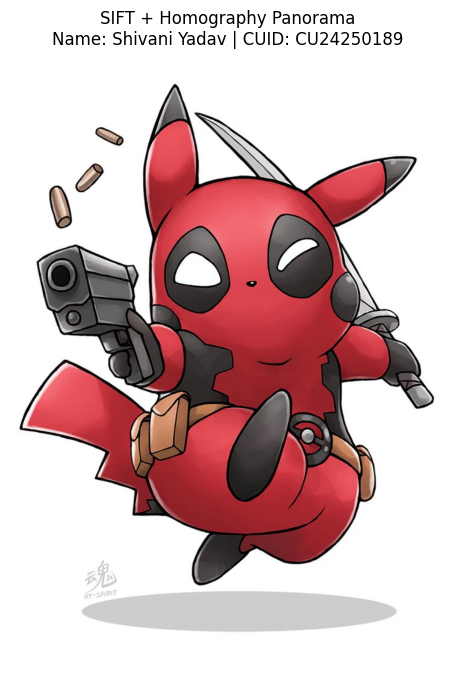

Panorama saved as: shivani_yadav_panorama.jpg


In [ ]:
# ============================================================
# Experiment 3: Panorama Stitcher using SIFT and Homography
# Name: Shivani Yadav
# CUID: CU24250189
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# Upload two overlapping images
uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 2:
    raise ValueError("Please upload TWO overlapping images.")

img1 = cv2.imread(filenames[0])
img2 = cv2.imread(filenames[1])

if img1 is None or img2 is None:
    raise ValueError("Images could not be loaded.")

# Resize images if very large
def resize_image(img, max_width=1000):
    h, w = img.shape[:2]

    if w > max_width:
        scale = max_width / w
        new_width = int(w * scale)
        new_height = int(h * scale)
        return cv2.resize(img, (new_width, new_height))

    return img

img1 = resize_image(img1)
img2 = resize_image(img2)

# Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# SIFT
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("Image 1 Keypoints:", len(kp1))
print("Image 2 Keypoints:", len(kp2))

# BF Matcher
bf = cv2.BFMatcher()

matches = bf.knnMatch(des1, des2, k=2)

# Lowe ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good Matches:", len(good_matches))

if len(good_matches) < 4:
    raise ValueError(
        "Not enough good matches to calculate homography. "
        "Use images with more overlap."
    )

# Extract matching points
src_pts = np.float32([
    kp1[m.queryIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

dst_pts = np.float32([
    kp2[m.trainIdx].pt for m in good_matches
]).reshape(-1, 1, 2)

# Calculate homography
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

if H is None:
    raise ValueError("Homography could not be calculated.")

inliers = mask.ravel().sum()

print("Homography Matrix:")
print(H)
print("Number of Inliers:", inliers)

# Warp first image
h1, w1 = img1.shape[:2]
h2, w2 = img2.shape[:2]

corners1 = np.float32([
    [0, 0],
    [w1, 0],
    [w1, h1],
    [0, h1]
]).reshape(-1, 1, 2)

corners2 = np.float32([
    [0, 0],
    [w2, 0],
    [w2, h2],
    [0, h2]
]).reshape(-1, 1, 2)

transformed_corners1 = cv2.perspectiveTransform(
    corners1,
    H
)

all_corners = np.concatenate(
    (transformed_corners1, corners2),
    axis=0
)

[x_min, y_min] = np.int32(
    all_corners.min(axis=0).ravel() - 0.5
)

[x_max, y_max] = np.int32(
    all_corners.max(axis=0).ravel() + 0.5
)

translation = np.array([
    [1, 0, -x_min],
    [0, 1, -y_min],
    [0, 0, 1]
])

# Warp image 1
result = cv2.warpPerspective(
    img1,
    translation @ H,
    (x_max - x_min, y_max - y_min)
)

# Place image 2
result[
    -y_min:-y_min + h2,
    -x_min:-x_min + w2
] = img2

# Convert BGR to RGB
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Display panorama
plt.figure(figsize=(18, 8))
plt.imshow(result_rgb)
plt.title(
    "SIFT + Homography Panorama\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)
plt.axis("off")
plt.show()

# Save result
cv2.imwrite(
    "shivani_yadav_panorama.jpg",
    result
)

print("Panorama saved as: shivani_yadav_panorama.jpg")

Name: Shivani Yadav
CUID: CU24250189


Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (5).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (5).jpg
Reference Keypoints: 644
Scene Keypoints: 888
Good Matches: 25


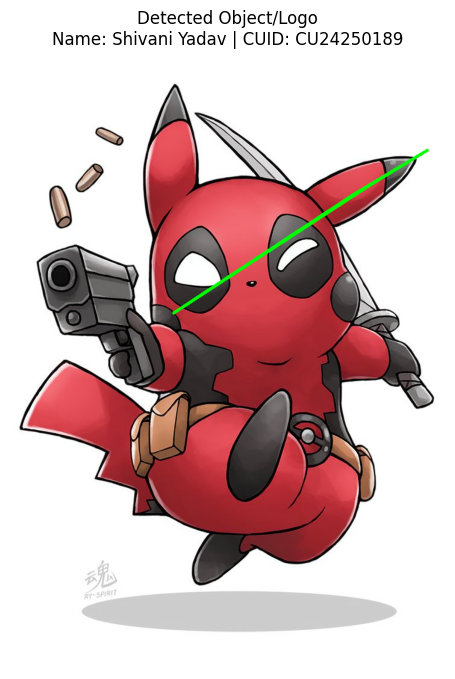

Object/Logo detected successfully.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# Upload:
# 1st image = reference object/logo
# 2nd image = scene
uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 2:
    raise ValueError(
        "Please upload TWO images: "
        "reference object and scene."
    )

reference = cv2.imread(filenames[0])
scene = cv2.imread(filenames[1])

if reference is None or scene is None:
    raise ValueError("Images could not be loaded.")

# Convert to grayscale
gray_reference = cv2.cvtColor(
    reference,
    cv2.COLOR_BGR2GRAY
)

gray_scene = cv2.cvtColor(
    scene,
    cv2.COLOR_BGR2GRAY
)

# SIFT detector
sift = cv2.SIFT_create()

# Detect features
kp1, des1 = sift.detectAndCompute(
    gray_reference,
    None
)

kp2, des2 = sift.detectAndCompute(
    gray_scene,
    None
)

print("Reference Keypoints:", len(kp1))
print("Scene Keypoints:", len(kp2))

# FLANN matcher
index_params = dict(
    algorithm=1,
    trees=5
)

search_params = dict(
    checks=50
)

flann = cv2.FlannBasedMatcher(
    index_params,
    search_params
)

matches = flann.knnMatch(
    des1,
    des2,
    k=2
)

# Ratio test
good_matches = []

for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

print("Good Matches:", len(good_matches))

# Check if enough matches exist
if len(good_matches) >= 4:

    src_pts = np.float32([
        kp1[m.queryIdx].pt
        for m in good_matches
    ]).reshape(-1, 1, 2)

    dst_pts = np.float32([
        kp2[m.trainIdx].pt
        for m in good_matches
    ]).reshape(-1, 1, 2)

    # Homography
    H, mask = cv2.findHomography(
        src_pts,
        dst_pts,
        cv2.RANSAC,
        5.0
    )

    if H is not None:

        h, w = gray_reference.shape

        corners = np.float32([
            [0, 0],
            [w, 0],
            [w, h],
            [0, h]
        ]).reshape(-1, 1, 2)

        transformed_corners = cv2.perspectiveTransform(
            corners,
            H
        )

        # Draw object boundary
        scene_with_box = scene.copy()

        cv2.polylines(
            scene_with_box,
            [np.int32(transformed_corners)],
            True,
            (0, 255, 0),
            4
        )

        # Display
        scene_rgb = cv2.cvtColor(
            scene_with_box,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(12, 8))
        plt.imshow(scene_rgb)
        plt.title(
            "Detected Object/Logo\n"
            "Name: Shivani Yadav | CUID: CU24250189"
        )
        plt.axis("off")
        plt.show()

        print("Object/Logo detected successfully.")

    else:
        print("Homography could not be calculated.")

else:
    print(
        "Object could not be reliably detected. "
        "Try images with a clearer reference object."
    )

Name: Shivani Yadav
CUID: CU24250189

Upload one image containing a person.


Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (7).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (7).jpg
Selected image: doreamon and her sister 🎀 (7).jpg

HOG Feature Extraction Completed
Number of HOG Features: 3780
Orientations: 9
Pixels per Cell: (8, 8)
Cells per Block: (2, 2)


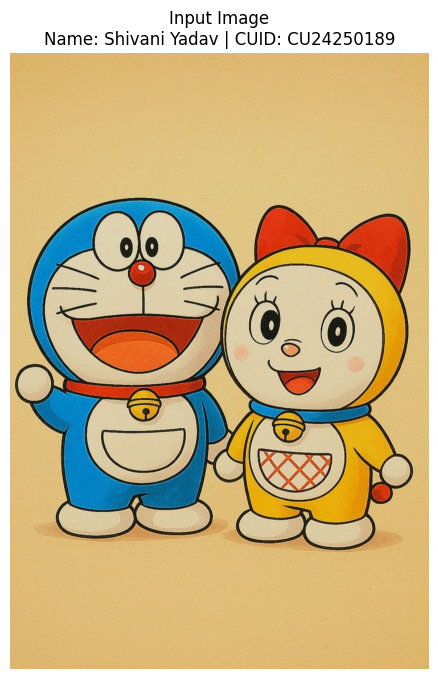

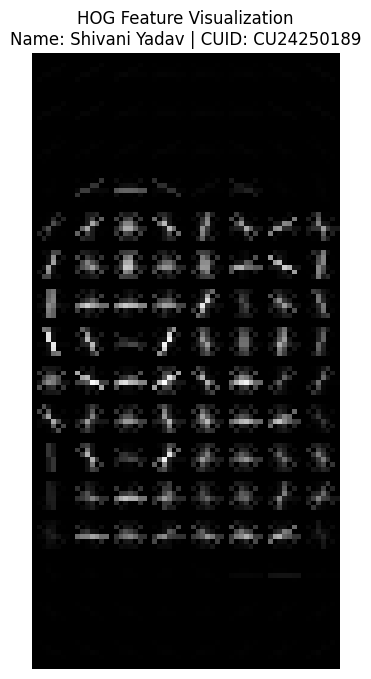

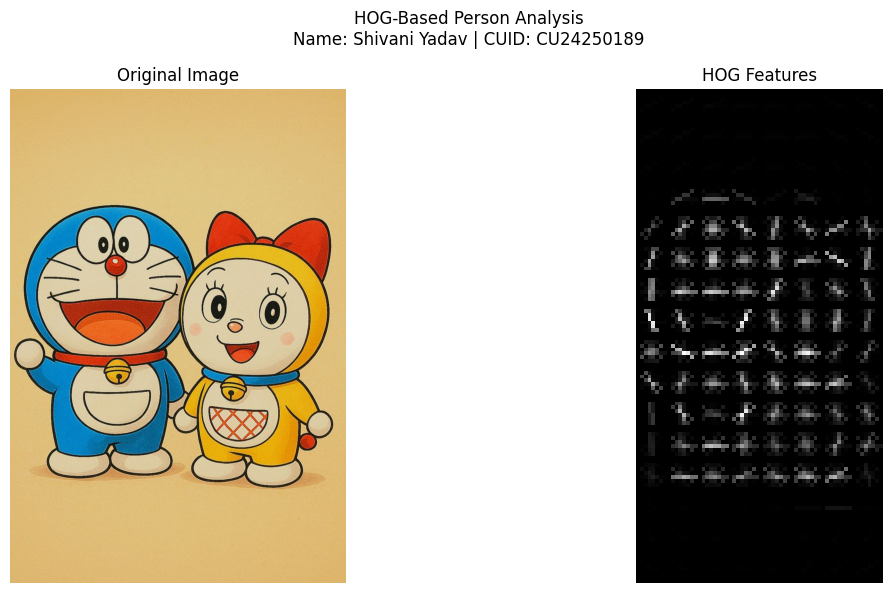


Experiment 5 completed successfully.
Name: Shivani Yadav
CUID: CU24250189


In [ ]:

!pip install -q scikit-image matplotlib

# ------------------------------------------------------------
# Import libraries
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# Upload image
# ------------------------------------------------------------

print("\nUpload one image containing a person.")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("Selected image:", filename)

# ------------------------------------------------------------
# Read image
# ------------------------------------------------------------

image = imread(filename)

# Remove alpha channel if image has one
if image.ndim == 3 and image.shape[2] == 4:
    image = image[:, :, :3]

# Convert to grayscale
gray = rgb2gray(image)

# Resize image
gray_resized = resize(
    gray,
    (128, 64)
)

# ------------------------------------------------------------
# Calculate HOG features
# ------------------------------------------------------------

features, hog_image = hog(
    gray_resized,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True
)

print("\nHOG Feature Extraction Completed")
print("Number of HOG Features:", len(features))
print("Orientations:", 9)
print("Pixels per Cell:", (8, 8))
print("Cells per Block:", (2, 2))

# ------------------------------------------------------------
# Display original image
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.title(
    "Input Image\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Display HOG visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(
    hog_image,
    cmap="gray"
)

plt.title(
    "HOG Feature Visualization\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.axis("off")
plt.show()

# ------------------------------------------------------------
# Display both results
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(
    hog_image,
    cmap="gray"
)
axes[1].set_title("HOG Features")
axes[1].axis("off")

plt.suptitle(
    "HOG-Based Person Analysis\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.tight_layout()
plt.show()

print("\nExperiment 5 completed successfully.")
print("Name: Shivani Yadav")
print("CUID: CU24250189")

Name: Shivani Yadav
CUID: CU24250189


Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (9).jpg


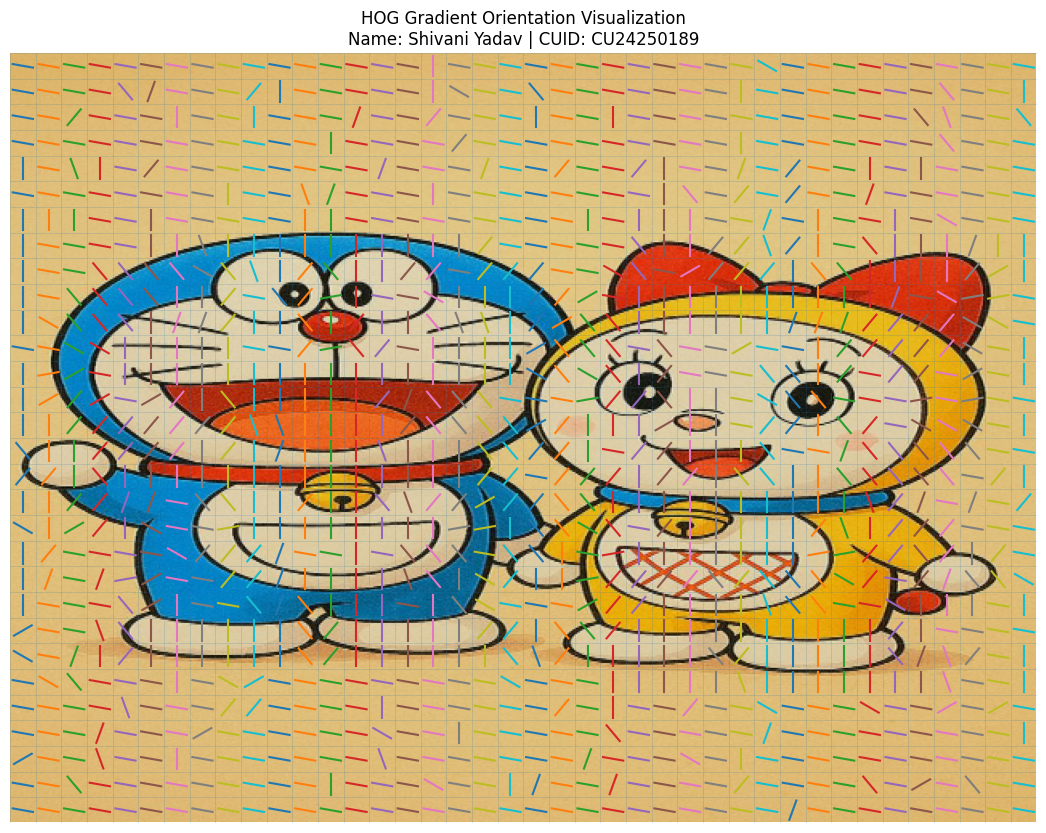

HOG visualization completed.
Cell Size: 16
Number of Orientation Bins: 9
Bin Angle: 20.0 degrees


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
image = cv2.imread(filename)

if image is None:
    raise ValueError("Image could not be loaded.")

# Resize for visualization
image = cv2.resize(
    image,
    (640, 480)
)

# Convert to grayscale
gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

# Calculate X and Y gradients
gx = cv2.Sobel(
    gray,
    cv2.CV_32F,
    1,
    0,
    ksize=1
)

gy = cv2.Sobel(
    gray,
    cv2.CV_32F,
    0,
    1,
    ksize=1
)

# Calculate magnitude and angle
magnitude, angle = cv2.cartToPolar(
    gx,
    gy,
    angleInDegrees=True
)

# HOG parameters
cell_size = 16
num_bins = 9
bin_size = 180 / num_bins

# Convert image to RGB
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# Create figure
plt.figure(figsize=(14, 10))
plt.imshow(image_rgb)

height, width = gray.shape

# Draw HOG cells
for y in range(
    0,
    height - cell_size + 1,
    cell_size
):

    for x in range(
        0,
        width - cell_size + 1,
        cell_size
    ):

        # Get cell values
        cell_mag = magnitude[
            y:y + cell_size,
            x:x + cell_size
        ]

        cell_angle = angle[
            y:y + cell_size,
            x:x + cell_size
        ]

        # Calculate histogram
        histogram = np.zeros(num_bins)

        for i in range(cell_size):
            for j in range(cell_size):

                mag = cell_mag[i, j]

                ang = cell_angle[i, j] % 180

                bin_index = int(
                    ang / bin_size
                )

                if bin_index >= num_bins:
                    bin_index = num_bins - 1

                histogram[bin_index] += mag

        # Dominant orientation
        dominant_bin = np.argmax(histogram)

        dominant_angle = (
            dominant_bin + 0.5
        ) * bin_size

        # Center of cell
        cx = x + cell_size / 2
        cy = y + cell_size / 2

        # Line length
        line_length = (
            0.4 * cell_size *
            (histogram[dominant_bin] /
             (histogram.max() + 1e-6))
        )

        # Convert angle to radians
        theta = np.deg2rad(
            dominant_angle
        )

        dx = line_length * np.cos(theta)
        dy = line_length * np.sin(theta)

        # Draw orientation line
        plt.plot(
            [cx - dx, cx + dx],
            [cy - dy, cy + dy],
            linewidth=1.5
        )

# Draw cell grid
for x in range(0, width + 1, cell_size):
    plt.axvline(
        x,
        linewidth=0.4,
        alpha=0.3
    )

for y in range(0, height + 1, cell_size):
    plt.axhline(
        y,
        linewidth=0.4,
        alpha=0.3
    )

plt.title(
    "HOG Gradient Orientation Visualization\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.xlim(0, width)
plt.ylim(height, 0)
plt.axis("off")
plt.show()

print("HOG visualization completed.")
print("Cell Size:", cell_size)
print("Number of Orientation Bins:", num_bins)
print("Bin Angle:", bin_size, "degrees")

Name: Shivani Yadav
CUID: CU24250189

Upload TWO images.
For best results, use the same or nearly identical image.


Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (10).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (8).jpg

Image 1 Keypoints: 644
Image 2 Keypoints: 888

Total Good Matches: 42
SIFT Similarity Score: 6.52%
Result: Different Images


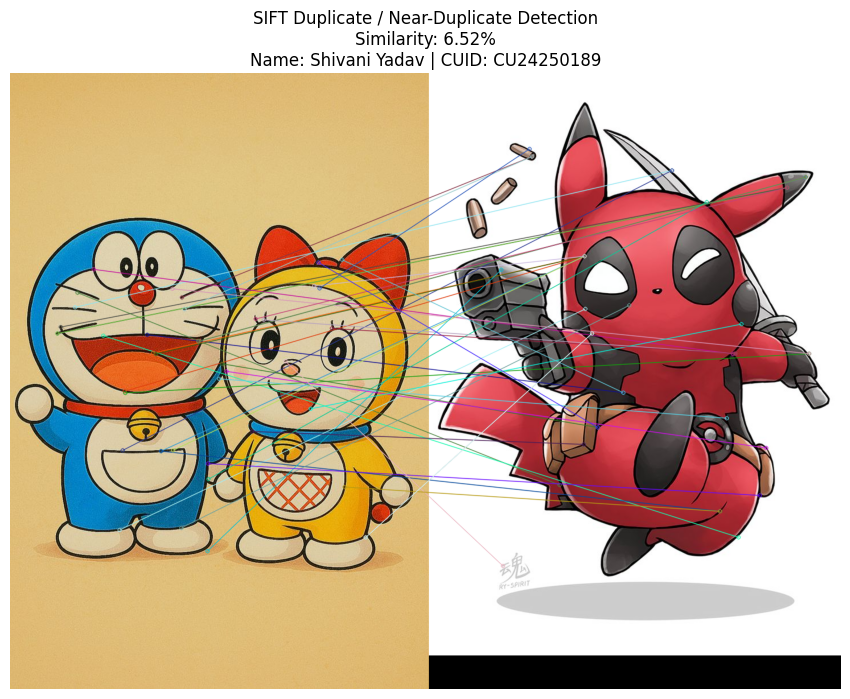


Experiment 7 completed successfully.


In [ ]:
# Experiment 7: Duplicate / Near-Duplicate Image Detector
!pip install -q opencv-contrib-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# Upload TWO images
# ------------------------------------------------------------

print("\nUpload TWO images.")
print("For best results, use the same or nearly identical image.")

uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) != 2:
    raise ValueError(
        "Please upload exactly TWO images."
    )

# ------------------------------------------------------------
# Read images
# ------------------------------------------------------------

image1 = cv2.imread(filenames[0])
image2 = cv2.imread(filenames[1])

if image1 is None or image2 is None:
    raise ValueError("Could not read one or both images.")

gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

# ------------------------------------------------------------
# Create SIFT detector
# ------------------------------------------------------------

if not hasattr(cv2, "SIFT_create"):
    raise AttributeError(
        "SIFT is unavailable. Please restart the Colab runtime "
        "after installing opencv-contrib-python."
    )

sift = cv2.SIFT_create()

# Detect keypoints and descriptors
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("\nImage 1 Keypoints:", len(kp1))
print("Image 2 Keypoints:", len(kp2))

if des1 is None or des2 is None:
    raise ValueError(
        "SIFT could not find enough features in one of the images."
    )

# ------------------------------------------------------------
# Match SIFT descriptors
# ------------------------------------------------------------

bf = cv2.BFMatcher(
    cv2.NORM_L2,
    crossCheck=False
)

matches = bf.knnMatch(
    des1,
    des2,
    k=2
)

# ------------------------------------------------------------
# Lowe's Ratio Test
# ------------------------------------------------------------

good_matches = []

for pair in matches:
    if len(pair) == 2:
        m, n = pair

        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

# ------------------------------------------------------------
# Calculate similarity
# ------------------------------------------------------------

total_keypoints = min(
    len(kp1),
    len(kp2)
)

if total_keypoints > 0:
    similarity = (
        len(good_matches) /
        total_keypoints
    ) * 100
else:
    similarity = 0

print("\nTotal Good Matches:", len(good_matches))
print("SIFT Similarity Score: {:.2f}%".format(similarity))

# ------------------------------------------------------------
# Classification
# ------------------------------------------------------------

if similarity >= 30:
    result = "Likely Duplicate / Near-Duplicate"
elif similarity >= 10:
    result = "Possibly Similar"
else:
    result = "Different Images"

print("Result:", result)

# ------------------------------------------------------------
# Draw matches
# ------------------------------------------------------------

match_image = cv2.drawMatches(
    image1,
    kp1,
    image2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

match_image = cv2.cvtColor(
    match_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(18, 8))
plt.imshow(match_image)

plt.title(
    "SIFT Duplicate / Near-Duplicate Detection\n"
    f"Similarity: {similarity:.2f}%\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.axis("off")
plt.show()

print("\nExperiment 7 completed successfully.")


Name: Shivani Yadav
CUID: CU24250189

Upload ONE image.


Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (10).jpg

Original Keypoints: 888
Rotated Keypoints: 1009
Scaled Keypoints: 1100

Rotation Test
Good Matches: 553
Similarity: 62.27 %

Scale Test
Good Matches: 502
Similarity: 56.53 %


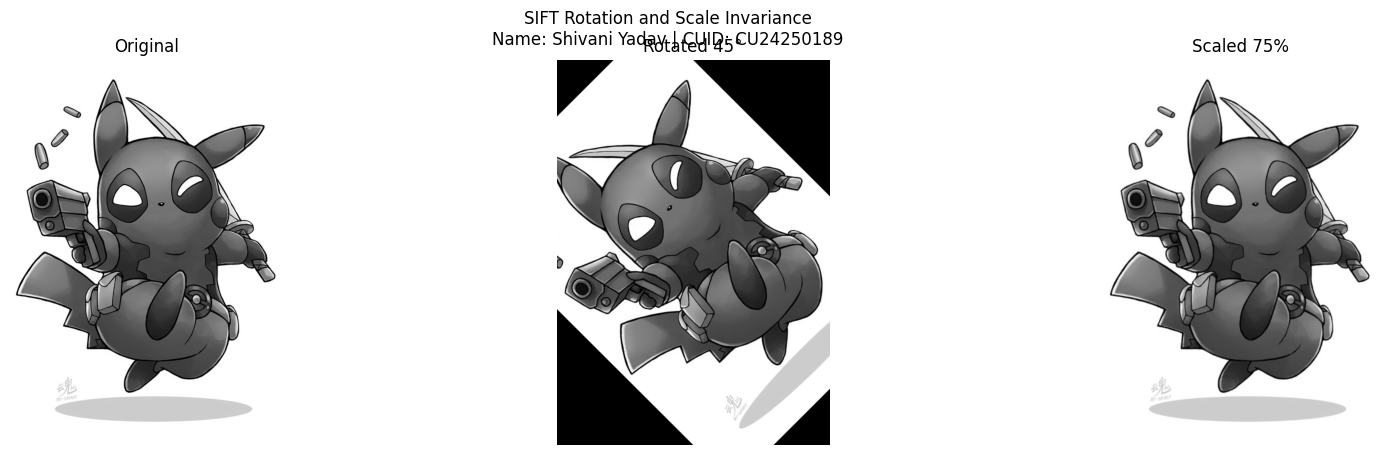


Experiment 8 completed successfully.


In [ ]:
# Experiment 8: SIFT Rotation and Scale Invariance Tester
!pip install -q opencv-contrib-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# Upload ONE image
# ------------------------------------------------------------

print("\nUpload ONE image.")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

image = cv2.imread(filename)

if image is None:
    raise ValueError("Image could not be loaded.")

# ------------------------------------------------------------
# Create rotated and scaled image
# ------------------------------------------------------------

gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

height, width = gray.shape

# Rotation
center = (
    width // 2,
    height // 2
)

rotation_matrix = cv2.getRotationMatrix2D(
    center,
    45,
    1.0
)

rotated = cv2.warpAffine(
    gray,
    rotation_matrix,
    (width, height)
)

# Scaling
scaled = cv2.resize(
    gray,
    None,
    fx=0.75,
    fy=0.75
)

# Resize scaled image back to original size
scaled = cv2.resize(
    scaled,
    (width, height)
)

# ------------------------------------------------------------
# Create SIFT
# ------------------------------------------------------------

if not hasattr(cv2, "SIFT_create"):
    raise AttributeError(
        "SIFT is unavailable."
    )

sift = cv2.SIFT_create()

# Original
kp_original, des_original = sift.detectAndCompute(
    gray,
    None
)

# Rotated
kp_rotated, des_rotated = sift.detectAndCompute(
    rotated,
    None
)

# Scaled
kp_scaled, des_scaled = sift.detectAndCompute(
    scaled,
    None
)

print("\nOriginal Keypoints:", len(kp_original))
print("Rotated Keypoints:", len(kp_rotated))
print("Scaled Keypoints:", len(kp_scaled))

# ------------------------------------------------------------
# Function to calculate matching percentage
# ------------------------------------------------------------

def calculate_matches(des1, des2):

    if des1 is None or des2 is None:
        return 0, 0

    matcher = cv2.BFMatcher(
        cv2.NORM_L2
    )

    matches = matcher.knnMatch(
        des1,
        des2,
        k=2
    )

    good = []

    for pair in matches:
        if len(pair) == 2:
            m, n = pair

            if m.distance < 0.75 * n.distance:
                good.append(m)

    minimum_features = min(
        len(des1),
        len(des2)
    )

    if minimum_features == 0:
        percentage = 0
    else:
        percentage = (
            len(good) /
            minimum_features
        ) * 100

    return len(good), percentage


# ------------------------------------------------------------
# Compare original with rotated
# ------------------------------------------------------------

rotated_matches, rotated_score = calculate_matches(
    des_original,
    des_rotated
)

# Compare original with scaled
scaled_matches, scaled_score = calculate_matches(
    des_original,
    des_scaled
)

print("\nRotation Test")
print("Good Matches:", rotated_matches)
print("Similarity:", round(rotated_score, 2), "%")

print("\nScale Test")
print("Good Matches:", scaled_matches)
print("Similarity:", round(scaled_score, 2), "%")

# ------------------------------------------------------------
# Display images
# ------------------------------------------------------------

plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rotated, cmap="gray")
plt.title("Rotated 45°")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(scaled, cmap="gray")
plt.title("Scaled 75%")
plt.axis("off")

plt.suptitle(
    "SIFT Rotation and Scale Invariance\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.show()

print("\nExperiment 8 completed successfully.")

Name: Shivani Yadav
CUID: CU24250189

Upload 1 QUERY image and at least 3 DATABASE images.
The FIRST uploaded image will be treated as the query.


Saving download (1).jpg to download (1).jpg
Saving download.jpg to download.jpg
Saving doreamon and her sister 🎀.jpg to doreamon and her sister 🎀 (12).jpg
Saving 30 Best Pikachu Illustration Ideas You Should Check.jpg to 30 Best Pikachu Illustration Ideas You Should Check (11).jpg

Query Image:
download (1).jpg

Database Images:
download.jpg
doreamon and her sister 🎀 (12).jpg
30 Best Pikachu Illustration Ideas You Should Check (11).jpg

SIFT IMAGE RETRIEVAL RESULTS
Rank 1: download.jpg --> Similarity = 32.94%
Rank 2: 30 Best Pikachu Illustration Ideas You Should Check (11).jpg --> Similarity = 6.76%
Rank 3: doreamon and her sister 🎀 (12).jpg --> Similarity = 4.04%


/tmp/ipykernel_1962/303689399.py:224: UserWarning: Glyph 127872 (\N{RIBBON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127872 (\N{RIBBON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


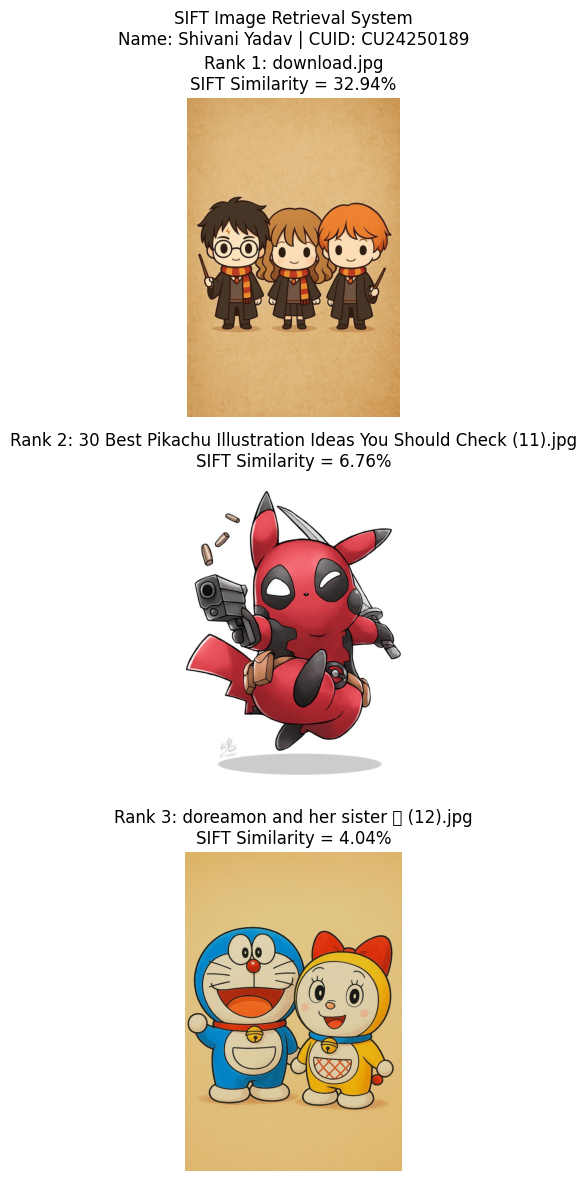


Experiment 9 completed successfully.


In [ ]:
# Experiment 9: SIFT-Based Image Retrieval System

!pip install -q opencv-contrib-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# Upload images
# ------------------------------------------------------------

print("\nUpload 1 QUERY image and at least 3 DATABASE images.")
print("The FIRST uploaded image will be treated as the query.")

uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) < 4:
    raise ValueError(
        "Please upload at least 4 images: "
        "1 query + 3 database images."
    )

query_filename = filenames[0]

database_filenames = filenames[1:]

print("\nQuery Image:")
print(query_filename)

print("\nDatabase Images:")
for name in database_filenames:
    print(name)

# ------------------------------------------------------------
# Create SIFT
# ------------------------------------------------------------

if not hasattr(cv2, "SIFT_create"):
    raise AttributeError(
        "SIFT is unavailable."
    )

sift = cv2.SIFT_create()

# ------------------------------------------------------------
# Extract SIFT descriptors
# ------------------------------------------------------------

def get_descriptors(filename):

    image = cv2.imread(filename)

    if image is None:
        return None, None

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    keypoints, descriptors = sift.detectAndCompute(
        gray,
        None
    )

    return keypoints, descriptors


query_kp, query_des = get_descriptors(
    query_filename
)

if query_des is None:
    raise ValueError(
        "No SIFT descriptors found in query image."
    )

# ------------------------------------------------------------
# Calculate similarity
# ------------------------------------------------------------

def calculate_similarity(
    query_des,
    database_des
):

    if database_des is None:
        return 0

    matcher = cv2.BFMatcher(
        cv2.NORM_L2
    )

    matches = matcher.knnMatch(
        query_des,
        database_des,
        k=2
    )

    good_matches = []

    for pair in matches:

        if len(pair) == 2:

            m, n = pair

            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    minimum_features = min(
        len(query_des),
        len(database_des)
    )

    if minimum_features == 0:
        return 0

    score = (
        len(good_matches) /
        minimum_features
    ) * 100

    return score


# ------------------------------------------------------------
# Search database
# ------------------------------------------------------------

results = []

for filename in database_filenames:

    kp, des = get_descriptors(filename)

    score = calculate_similarity(
        query_des,
        des
    )

    results.append(
        (filename, score)
    )

# ------------------------------------------------------------
# Sort results
# ------------------------------------------------------------

results.sort(
    key=lambda x: x[1],
    reverse=True
)

# ------------------------------------------------------------
# Display ranking
# ------------------------------------------------------------

print("\n======================================")
print("SIFT IMAGE RETRIEVAL RESULTS")
print("======================================")

for rank, (filename, score) in enumerate(
    results,
    start=1
):

    print(
        f"Rank {rank}: {filename} "
        f"--> Similarity = {score:.2f}%"
    )

# ------------------------------------------------------------
# Display images according to ranking
# ------------------------------------------------------------

number_to_display = min(
    len(results),
    5
)

plt.figure(
    figsize=(15, 4 * number_to_display)
)

for i in range(number_to_display):

    filename, score = results[i]

    image = cv2.imread(filename)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(
        number_to_display,
        1,
        i + 1
    )

    plt.imshow(image)

    plt.title(
        f"Rank {i + 1}: {filename}\n"
        f"SIFT Similarity = {score:.2f}%"
    )

    plt.axis("off")

plt.suptitle(
    "SIFT Image Retrieval System\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.tight_layout()
plt.show()

print("\nExperiment 9 completed successfully.")

Name: Shivani Yadav
CUID: CU24250189

Upload TWO images.
Image 1 = first object/image
Image 2 = second object/image


Saving download (1).jpg to download (1) (1).jpg
Saving download.jpg to download (2).jpg

Running SIFT...
SIFT Keypoints Image 1: 2331
SIFT Keypoints Image 2: 686
SIFT Good Matches: 226
SIFT Similarity: 32.94 %
SIFT Processing Time: 0.4141 seconds

Running HOG...
HOG Feature Length: 3780
HOG Similarity: 54.58 %
HOG Processing Time: 0.0671 seconds

        SIFT vs HOG BENCHMARK
Method         Similarity          Time (sec)     
----------------------------------------------
SIFT           32.94%            0.4141
HOG            54.58%            0.0671
----------------------------------------------


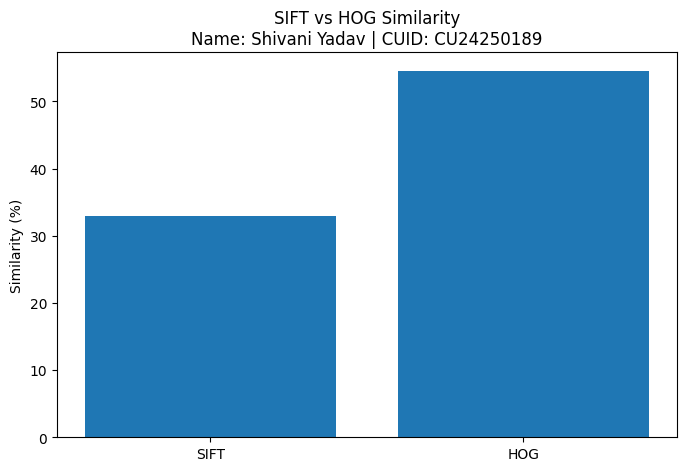

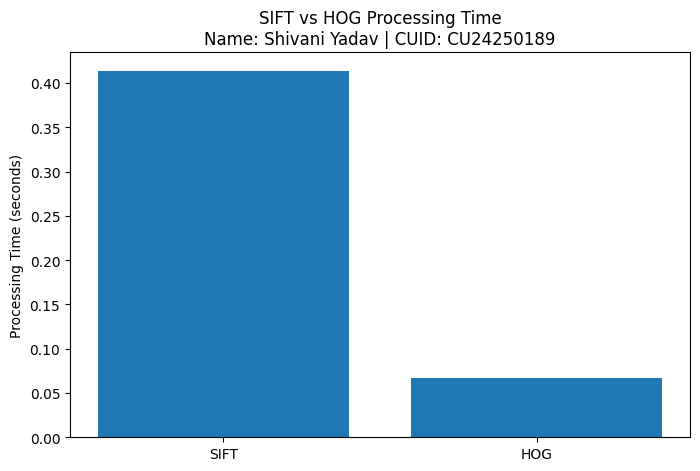


Experiment 10 completed successfully.
Name: Shivani Yadav
CUID: CU24250189


In [ ]:
# Experiment 10: SIFT vs HOG Benchmarking
!pip install -q opencv-contrib-python scikit-image matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

from google.colab import files

from skimage.io import imread
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog

print("Name: Shivani Yadav")
print("CUID: CU24250189")

# ------------------------------------------------------------
# Upload TWO images
# ------------------------------------------------------------

print("\nUpload TWO images.")
print("Image 1 = first object/image")
print("Image 2 = second object/image")

uploaded = files.upload()

filenames = list(uploaded.keys())

if len(filenames) != 2:
    raise ValueError(
        "Please upload exactly TWO images."
    )

# ------------------------------------------------------------
# Read images
# ------------------------------------------------------------

image1 = cv2.imread(filenames[0])
image2 = cv2.imread(filenames[1])

if image1 is None or image2 is None:
    raise ValueError(
        "Could not load one or both images."
    )

gray1 = cv2.cvtColor(
    image1,
    cv2.COLOR_BGR2GRAY
)

gray2 = cv2.cvtColor(
    image2,
    cv2.COLOR_BGR2GRAY
)

# ------------------------------------------------------------
# SIFT Benchmark
# ------------------------------------------------------------

print("\nRunning SIFT...")

start_time = time.time()

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(
    gray1,
    None
)

kp2, des2 = sift.detectAndCompute(
    gray2,
    None
)

sift_time = time.time() - start_time

sift_matches = 0
sift_score = 0

if des1 is not None and des2 is not None:

    matcher = cv2.BFMatcher(
        cv2.NORM_L2
    )

    matches = matcher.knnMatch(
        des1,
        des2,
        k=2
    )

    good_matches = []

    for pair in matches:

        if len(pair) == 2:

            m, n = pair

            if m.distance < 0.75 * n.distance:
                good_matches.append(m)

    sift_matches = len(good_matches)

    minimum_features = min(
        len(des1),
        len(des2)
    )

    if minimum_features > 0:
        sift_score = (
            sift_matches /
            minimum_features
        ) * 100

print("SIFT Keypoints Image 1:", len(kp1))
print("SIFT Keypoints Image 2:", len(kp2))
print("SIFT Good Matches:", sift_matches)
print("SIFT Similarity:", round(sift_score, 2), "%")
print("SIFT Processing Time:", round(sift_time, 4), "seconds")

# ------------------------------------------------------------
# HOG Benchmark
# ------------------------------------------------------------

print("\nRunning HOG...")

start_time = time.time()

# Convert to grayscale float images
gray1_float = gray1 / 255.0
gray2_float = gray2 / 255.0

# Resize both images to same dimensions
gray1_resized = resize(
    gray1_float,
    (128, 64)
)

gray2_resized = resize(
    gray2_float,
    (128, 64)
)

# Extract HOG features
hog1 = hog(
    gray1_resized,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

hog2 = hog(
    gray2_resized,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

hog_time = time.time() - start_time

# ------------------------------------------------------------
# Calculate HOG similarity
# ------------------------------------------------------------

dot_product = np.dot(
    hog1,
    hog2
)

norm1 = np.linalg.norm(hog1)
norm2 = np.linalg.norm(hog2)

if norm1 == 0 or norm2 == 0:
    hog_similarity = 0
else:
    hog_similarity = (
        dot_product /
        (norm1 * norm2)
    ) * 100

print("HOG Feature Length:", len(hog1))
print("HOG Similarity:", round(hog_similarity, 2), "%")
print("HOG Processing Time:", round(hog_time, 4), "seconds")

# ------------------------------------------------------------
# Display benchmark results
# ------------------------------------------------------------

print("\n==============================================")
print("SIFT vs HOG BENCHMARK")
print("==============================================")
print(
    f"{'Method':<15}"
    f"{'Similarity':<20}"
    f"{'Time (sec)':<15}"
)
print("----------------------------------------------")
print(
    f"{'SIFT':<15}"
    f"{sift_score:.2f}%"
    f"{'':<12}"
    f"{sift_time:.4f}"
)
print(
    f"{'HOG':<15}"
    f"{hog_similarity:.2f}%"
    f"{'':<12}"
    f"{hog_time:.4f}"
)
print("----------------------------------------------")
# Create comparison chart
# ------------------------------------------------------------

methods = [
    "SIFT",
    "HOG"
]

similarities = [
    sift_score,
    hog_similarity
]

times = [
    sift_time,
    hog_time
]

# Similarity chart
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    similarities
)

plt.ylabel(
    "Similarity (%)"
)

plt.title(
    "SIFT vs HOG Similarity\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.show()

# Processing time chart
plt.figure(figsize=(8, 5))

plt.bar(
    methods,
    times
)

plt.ylabel(
    "Processing Time (seconds)"
)

plt.title(
    "SIFT vs HOG Processing Time\n"
    "Name: Shivani Yadav | CUID: CU24250189"
)

plt.show()

print("\nExperiment 10 completed successfully.")
print("Name: Shivani Yadav")
print("CUID: CU24250189")